# House Price Prediction
Classifying houses into **Low / Medium / High** price categories using multiple ML models.

In [3]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Save model
import pickle

## 1. Load Dataset

In [4]:
df = pd.read_csv("house_price.csv")

df.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1.792425e+06


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 19)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

In [7]:
df.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04
mean,2752.970540,3.496040,2.498040,1.997060,19.573740,14.968700,0.500540,0.497300,0.500280,0.496220,0.501100,0.498320,0.498320,0.500040,5.006444,5065.94598,1.030261e+06
std,1297.148134,1.712146,1.117704,0.815368,11.552502,8.363714,0.500005,0.499998,0.500005,0.499991,0.500004,0.500002,0.500002,0.500005,2.876776,2864.34322,4.580199e+05
min,500.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000311,100.00000,9.090069e+04
25%,1630.000000,2.000000,1.000000,1.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.523018,2575.00000,6.357375e+05
50%,2756.000000,3.000000,2.000000,2.000000,20.000000,15.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.022946,5060.50000,1.031763e+06
75%,3872.000000,5.000000,3.000000,3.000000,30.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.479632,7543.00000,1.423102e+06
max,4999.000000,6.000000,4.000000,3.000000,39.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999869,9999.00000,1.996474e+06


## 2. Data Cleaning

In [8]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'garage',
       'parking', 'garden', 'security', 'school_nearby', 'hospital_nearby',
       'shopping_mall_nearby', 'public_transport', 'crime_rate',
       'population_density', 'location', 'income_level', 'price'],
      dtype='object')

In [9]:
print("Duplicate rows before removing:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removing:", df.duplicated().sum())

Duplicate rows before removing: 0
Duplicate rows after removing: 0


In [10]:
df.isnull().sum()

area                    0
bedrooms                0
bathrooms               0
floors                  0
age                     0
distance                0
garage                  0
parking                 0
garden                  0
security                0
school_nearby           0
hospital_nearby         0
shopping_mall_nearby    0
public_transport        0
crime_rate              0
population_density      0
location                0
income_level            0
price                   0
dtype: int64

### Fix Inconsistent Category Labels

In [11]:
df["location"] = df["location"].str.lower().str.strip()
df["income_level"] = df["income_level"].str.lower().str.strip()

In [12]:
df["location"] = df["location"].replace({
    "premum": "premium",
    "med": "medium"
})

df["income_level"] = df["income_level"].replace({
    "middle": "mid",
    "medium": "mid"
})

### Remove Invalid Rows

In [13]:
df = df[df["area"] > 0]
df = df[df["bedrooms"] > 0]
df = df[df["bathrooms"] > 0]
df = df[df["floors"] > 0]
df = df[df["age"] >= 0]
df = df[df["distance"] >= 0]
df = df[df["price"] > 0]

In [14]:
binary_cols = [
    "garage", "parking", "garden", "security",
    "school_nearby", "hospital_nearby",
    "shopping_mall_nearby", "public_transport"
]

for col in binary_cols:
    print(col, df[col].unique())

garage [0 1]
parking [0 1]
garden [1 0]
security [0 1]
school_nearby [1 0]
hospital_nearby [0 1]
shopping_mall_nearby [1 0]
public_transport [0 1]


In [15]:
for col in binary_cols:
    df = df[df[col].isin([0, 1])]

In [16]:
print(df["location"].unique())
print(df["income_level"].unique())

['premium' 'low' 'medium']
['low' 'mid' 'high']


## 3. Encoding Categorical Features

In [17]:
df["location"] = df["location"].map({
    "low": 0,
    "medium": 1,
    "premium": 2
})

df["income_level"] = df["income_level"].map({
    "low": 0,
    "mid": 1,
    "high": 2
})

In [18]:
df = df.dropna()

In [19]:
df.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,2,0,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,0,0,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,2,1,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,1,0,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,0,1,1.792425e+06


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

## 4. Exploratory Data Analysis

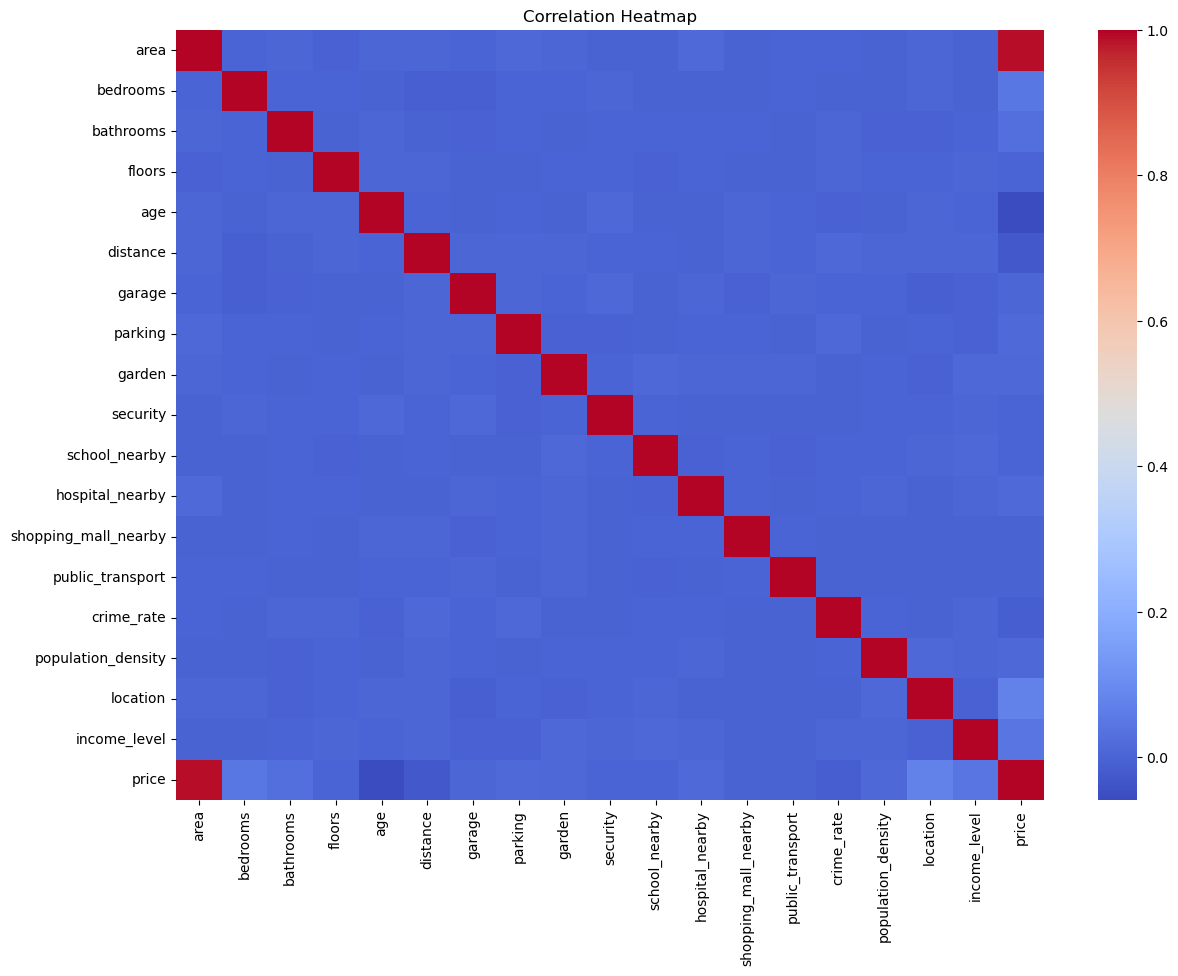

In [21]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 5. Target Variable: Price Category

In [22]:
df["price_category"] = pd.qcut(
    df["price"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["price", "price_category"]].head()

,price,price_category
0,5.952493e+05,Low
1,1.571208e+06,High
2,1.379943e+06,High
3,4.367819e+05,Low
4,1.792425e+06,High


In [23]:
df["price_category"].value_counts()

price_category
Low       16667
High      16667
Medium    16666
Name: count, dtype: int64

## 6. Train-Test Split & Feature Preparation

In [24]:
X = df.drop(["price", "price_category"], axis=1)
y = df["price_category"]

In [25]:
X.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,2,0
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,0,0
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,2,1
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,1,0
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,0,1


In [26]:
y.head()

0     Low
1    High
2    High
3     Low
4    High
Name: price_category, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [27]:
print("Input Features Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features Shape: (50000, 18)
Target Shape: (50000,)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40000, 18)
X_test: (10000, 18)
y_train: (40000,)
y_test: (10000,)


### Scaling & PCA

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [32]:
print("Original number of features:", X_train.shape[1])
print("Reduced number of features after PCA:", X_train_pca.shape[1])

Original number of features: 18
Reduced number of features after PCA: 18


## 7. Model Training & Comparison

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [34]:
results = []

for model_name, model in models.items():
    
    # Train the model
    model.fit(X_train_pca, y_train)
    
    # Predict on training data
    y_train_pred = model.predict(X_train_pca)
    
    # Predict on testing data
    y_test_pred = model.predict(X_test_pca)
    
    # Training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    
    # Testing accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Precision
    precision = precision_score(y_test, y_test_pred, average="weighted")
    
    # Recall
    recall = recall_score(y_test, y_test_pred, average="weighted")
    
    # F1 Score
    f1 = f1_score(y_test, y_test_pred, average="weighted")
    
    # Store results
    results.append([
        model_name,
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1
    ])

In [35]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.978750,0.9787,0.978690,0.9787,0.978693
1,KNN,0.825150,0.6948,0.685631,0.6948,0.688470
2,Naive Bayes,0.948675,0.9509,0.950810,0.9509,0.950841
3,Decision Tree,1.000000,0.6617,0.663979,0.6617,0.662771


In [36]:
results_df.sort_values(by="Testing Accuracy", ascending=False)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.978750,0.9787,0.978690,0.9787,0.978693
2,Naive Bayes,0.948675,0.9509,0.950810,0.9509,0.950841
1,KNN,0.825150,0.6948,0.685631,0.6948,0.688470
3,Decision Tree,1.000000,0.6617,0.663979,0.6617,0.662771


## 8. Best Model Selection & Evaluation

In [37]:
best_row = results_df.sort_values(by="Testing Accuracy", ascending=False).iloc[0]

best_model_name = best_row["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [38]:
best_model = models[best_model_name]

In [39]:
y_pred_best = best_model.predict(X_test_pca)

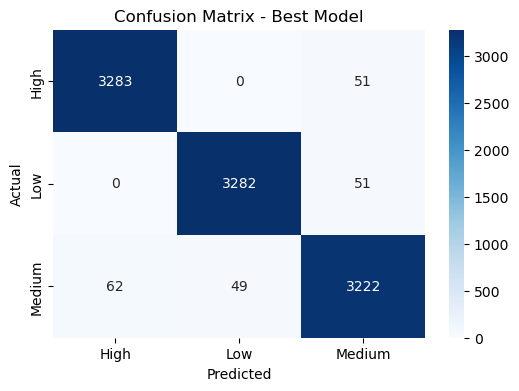

In [40]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Model")
plt.show()

In [41]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

        High       0.98      0.98      0.98      3334
         Low       0.99      0.98      0.98      3333
      Medium       0.97      0.97      0.97      3333

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



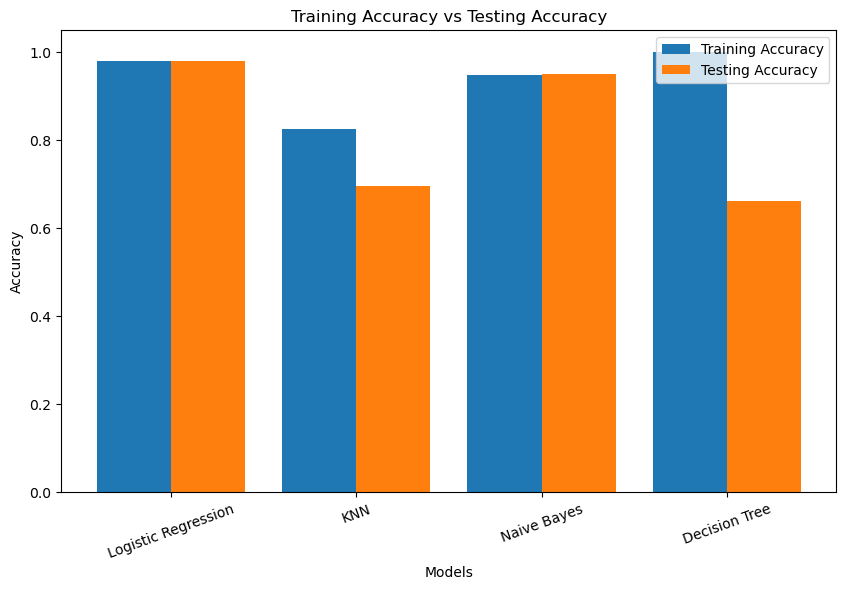

In [42]:
plt.figure(figsize=(10, 6))

x = np.arange(len(results_df["Model"]))

plt.bar(x - 0.2, results_df["Training Accuracy"], width=0.4, label="Training Accuracy")
plt.bar(x + 0.2, results_df["Testing Accuracy"], width=0.4, label="Testing Accuracy")

plt.xticks(x, results_df["Model"], rotation=20)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Testing Accuracy")
plt.legend()
plt.show()

In [43]:
best_model_result = results_df.sort_values(
    by="Testing Accuracy",
    ascending=False
).iloc[0]

print("Best Model Details:")
print(best_model_result)

Best Model Details:
Model                Logistic Regression
Training Accuracy                0.97875
Testing Accuracy                  0.9787
Precision                        0.97869
Recall                            0.9787
F1 Score                        0.978693
Name: 0, dtype: object


## 9. Save Model

In [44]:
final_model_data = {
    "model": best_model,
    "scaler": scaler,
    "pca": pca,
    "feature_names": X.columns.tolist()
}

with open("house_price_best_model.pkl", "wb") as file:
    pickle.dump(final_model_data, file)

print("Best model saved successfully!")

Best model saved successfully!


In [45]:
with open("house_price_best_model.pkl", "rb") as file:
    loaded_data = pickle.load(file)

loaded_model = loaded_data["model"]
loaded_scaler = loaded_data["scaler"]
loaded_pca = loaded_data["pca"]
feature_names = loaded_data["feature_names"]

print("Model loaded successfully!")

Model loaded successfully!


## 10. Inference on New Data

In [46]:
new_house = pd.DataFrame([{
    "area": 2500,
    "bedrooms": 3,
    "bathrooms": 2,
    "floors": 2,
    "age": 5,
    "distance": 8,
    "garage": 1,
    "parking": 1,
    "garden": 1,
    "security": 1,
    "school_nearby": 1,
    "hospital_nearby": 1,
    "shopping_mall_nearby": 0,
    "public_transport": 1,
    "crime_rate": 3.5,
    "population_density": 6000,
    "location": 2,
    "income_level": 1
}])

In [47]:
new_house = new_house[feature_names]

new_house_scaled = loaded_scaler.transform(new_house)

new_house_pca = loaded_pca.transform(new_house_scaled)

prediction = loaded_model.predict(new_house_pca)

print("Predicted House Price Category:", prediction[0])

Predicted House Price Category: Medium
